In [3]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import LabelEncoder

In [4]:
df=pd.read_csv('/content/train_v9rqX0R.csv')
test=pd.read_csv('/content/test_AbJTz2l.csv')

In [5]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
df.shape

(8523, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [8]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [9]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


/tmp/ipython-input-169/610123320.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Item_Weight'],bins=100)


<Axes: xlabel='Item_Weight', ylabel='Density'>

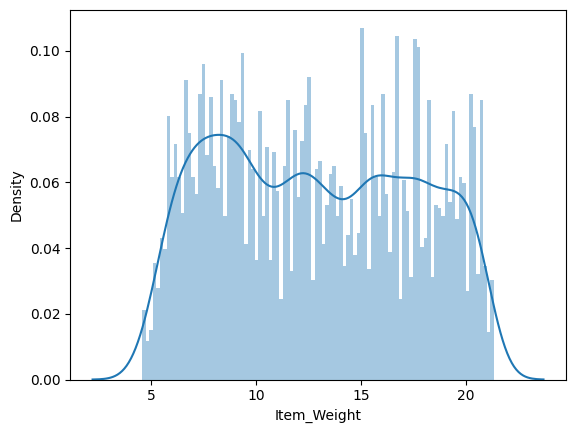

In [10]:
sns.distplot(df['Item_Weight'],bins=100)

In [11]:
df[df['Item_Weight']==np.nan]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales


In [12]:
df['Item_Weight'].fillna(0,inplace=True)

/tmp/ipython-input-169/1912017771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(0,inplace=True)


In [13]:
df[df['Item_Weight']==0].index

Index([   7,   18,   21,   23,   29,   36,   38,   39,   49,   59,
       ...
       8458, 8463, 8469, 8472, 8480, 8485, 8487, 8488, 8490, 8504],
      dtype='int64', length=1463)

In [14]:
ind=df[df['Item_Weight']==0].index

In [15]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [16]:
for i in ind:
    it=df.iloc[i,0]
    df.iloc[i,1]=np.mean(df[df['Item_Identifier']==it]['Item_Weight'])

In [17]:
df[df['Item_Weight']==0].index

Index([927, 1922, 4187, 5022], dtype='int64')

In [18]:
ind=df[df['Item_Weight']==0].index

In [19]:
df['Item_Weight'].replace(0,np.mean(df['Item_Weight']),inplace=True)

/tmp/ipython-input-169/191873287.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].replace(0,np.mean(df['Item_Weight']),inplace=True)


In [20]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


<Axes: xlabel='count', ylabel='Outlet_Size'>

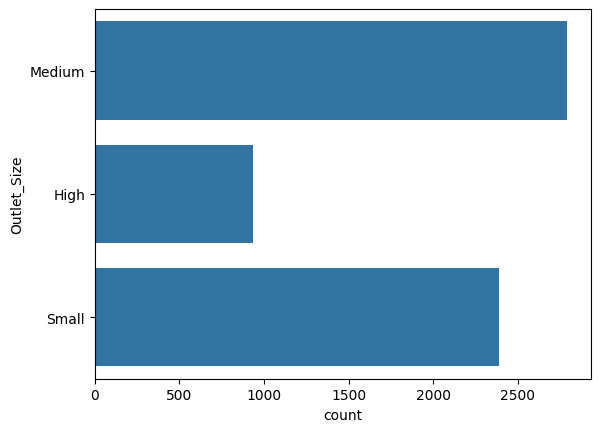

In [21]:
sns.countplot(df['Outlet_Size'])

In [22]:
df['Outlet_Size'].fillna('Missing',inplace=True)

/tmp/ipython-input-169/1408158407.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Outlet_Size'].fillna('Missing',inplace=True)


<Axes: xlabel='count', ylabel='Outlet_Size'>

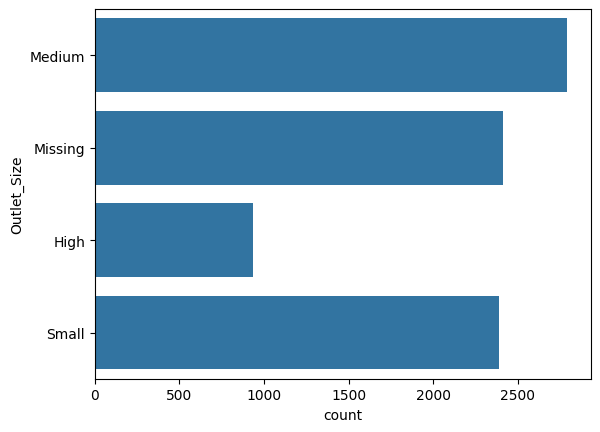

In [23]:
sns.countplot(df['Outlet_Size'])

In [24]:
df['Outlet_Size'].replace('Missing','Small',inplace=True)

In [25]:
test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [26]:
test.shape

(5681, 11)

In [27]:
test.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4705.000000,5681.000000,5681.000000,5681.000000
mean,12.695633,0.065684,141.023273,1997.828903
std,4.664849,0.051252,61.809091,8.372256
min,4.555000,0.000000,31.990000,1985.000000
25%,8.645000,0.027047,94.412000,1987.000000
50%,12.500000,0.054154,141.415400,1999.000000
75%,16.700000,0.093463,186.026600,2004.000000
max,21.350000,0.323637,266.588400,2009.000000


In [28]:
test.isnull().sum()

,0
Item_Identifier,0
Item_Weight,976
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1606
Outlet_Location_Type,0


In [29]:
test['Item_Weight'].fillna(0,inplace=True)

/tmp/ipython-input-169/216111785.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Item_Weight'].fillna(0,inplace=True)


In [30]:
ind=test[test['Item_Weight']==0].index

In [31]:
test.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')

In [32]:
for i in ind:
    it=test.iloc[i,0]
    test.iloc[i,1]=np.mean(test[test['Item_Identifier']==it]['Item_Weight'])

In [33]:
ind=test[test['Item_Weight']==0].index

In [34]:
test['Item_Weight'].replace(0,np.mean(test['Item_Weight']),inplace=True)

/tmp/ipython-input-169/2909988334.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Item_Weight'].replace(0,np.mean(test['Item_Weight']),inplace=True)


In [35]:
test.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1606
Outlet_Location_Type,0


In [36]:
test['Outlet_Size'].fillna('Small',inplace=True)

/tmp/ipython-input-169/1433117913.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Outlet_Size'].fillna('Small',inplace=True)


In [37]:
test.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [38]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [39]:
df['Item_Identifier'].value_counts(normalize=True)*100

,proportion
Item_Identifier,
FDW13,0.117330
FDG33,0.117330
FDX31,0.105597
FDT07,0.105597
NCY18,0.105597
...,...
FDO33,0.011733
FDK57,0.011733
FDT35,0.011733


In [40]:
df['Item_category']=df['Item_Identifier'].str[:2]

In [41]:
test['Item_category']=test['Item_Identifier'].str[:2]

In [42]:
df['new_item']=df['Item_Identifier'].str[-2:].astype('int')

In [43]:
test['new_item']=test['Item_Identifier'].str[-2:].astype('int')

In [44]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [45]:
df['Item_Fat_Content'].replace(['Low Fat','Regular','LF','reg','low fat'],['LF','REG','LF','REG','LF'],inplace=True)

/tmp/ipython-input-169/1508596498.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Fat_Content'].replace(['Low Fat','Regular','LF','reg','low fat'],['LF','REG','LF','REG','LF'],inplace=True)


In [46]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
LF,5517
REG,3006


In [47]:
test['Item_Fat_Content'].replace(['Low Fat','Regular','LF','reg','low fat'],['LF','REG','LF','REG','LF'],inplace=True)

/tmp/ipython-input-169/2320509489.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Item_Fat_Content'].replace(['Low Fat','Regular','LF','reg','low fat'],['LF','REG','LF','REG','LF'],inplace=True)


/tmp/ipython-input-169/3255610662.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Item_Visibility'],bins=100)


<Axes: xlabel='Item_Visibility', ylabel='Density'>

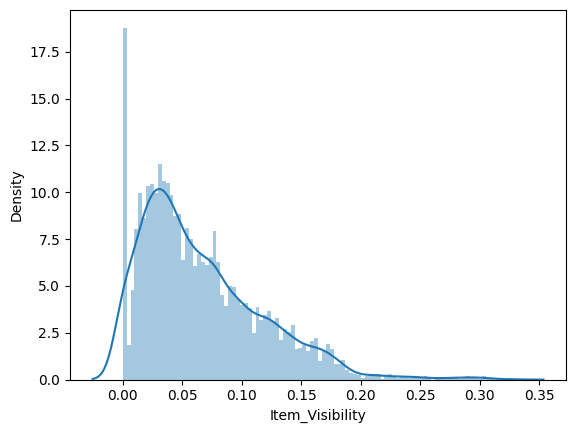

In [48]:
sns.distplot(df['Item_Visibility'],bins=100)

In [49]:
df[df['Item_Visibility']==0].head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_category,new_item
3,FDX07,19.200,REG,0.0,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,FD,7
4,NCD19,8.930,LF,0.0,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,NC,19
5,FDP36,10.395,REG,0.0,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088,FD,36
10,FDY07,11.800,LF,0.0,Fruits and Vegetables,45.5402,OUT049,1999,Medium,Tier 1,Supermarket Type1,1516.0266,FD,7
32,FDP33,18.700,LF,0.0,Snack Foods,256.6672,OUT018,2009,Medium,Tier 3,Supermarket Type2,3068.0064,FD,33


<Axes: xlabel='Item_Visibility', ylabel='Item_Outlet_Sales'>

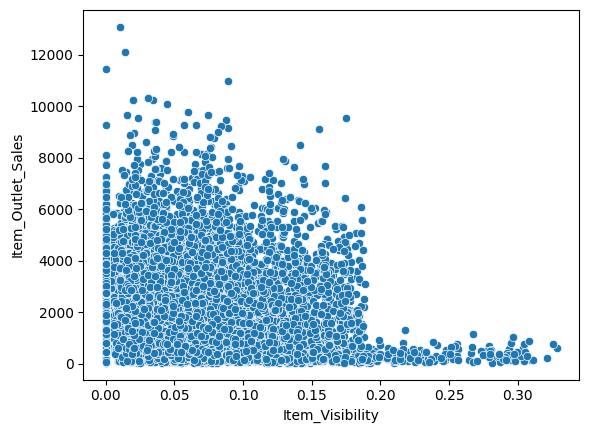

In [50]:
sns.scatterplot(x=df['Item_Visibility'],y=df['Item_Outlet_Sales'])

<Axes: xlabel='Item_Visibility', ylabel='Item_Weight'>

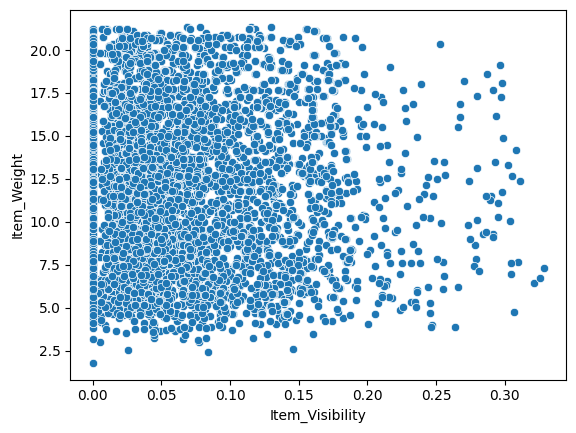

In [51]:
sns.scatterplot(x=df['Item_Visibility'],y=df['Item_Weight'])

In [52]:
ind=df[df['Item_Visibility']==0].index

In [53]:
for i in ind:
    it=df.iloc[i,1]
    df.iloc[i,3]=np.mean(df[df['Item_Weight']==it]['Item_Visibility'])

In [54]:
ind=test[test['Item_Visibility']==0].index

In [55]:
for i in ind:
    it=test.iloc[i,1]
    test.iloc[i,3]=np.mean(test[test['Item_Weight']==it]['Item_Visibility'])

<Axes: xlabel='count', ylabel='Item_Type'>

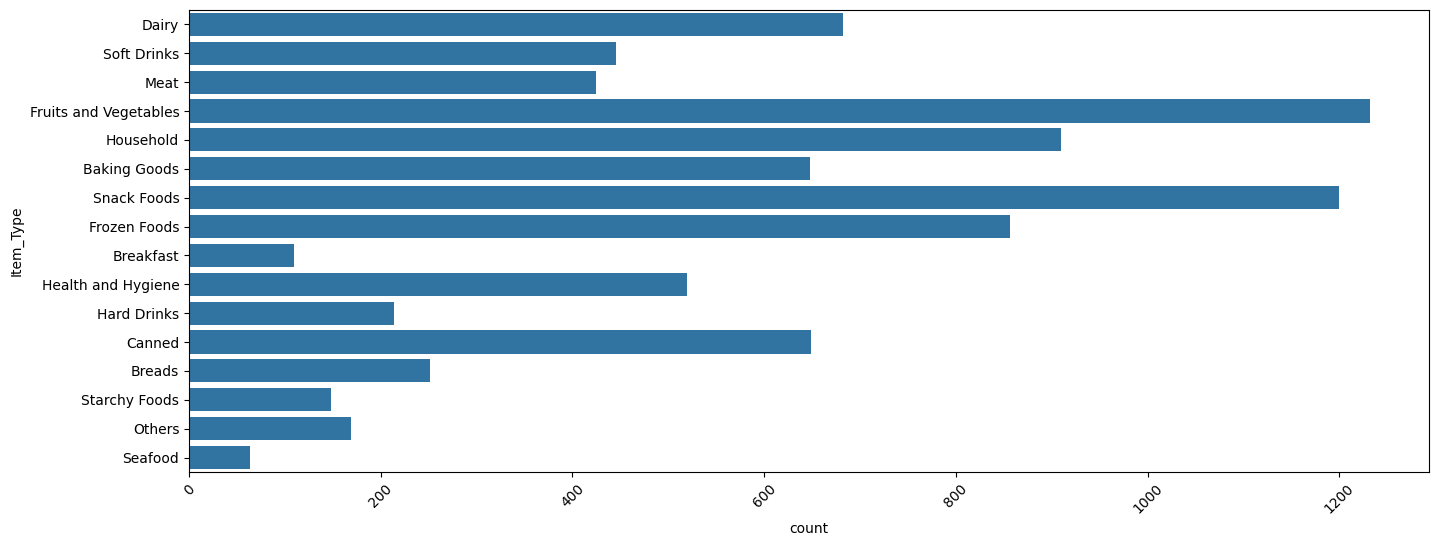

In [56]:
plt.figure(figsize=(16,6))
plt.xticks(rotation=45)
sns.countplot(df['Item_Type'])

/tmp/ipython-input-169/863907308.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Item_MRP'],bins=100)


<Axes: xlabel='Item_MRP', ylabel='Density'>

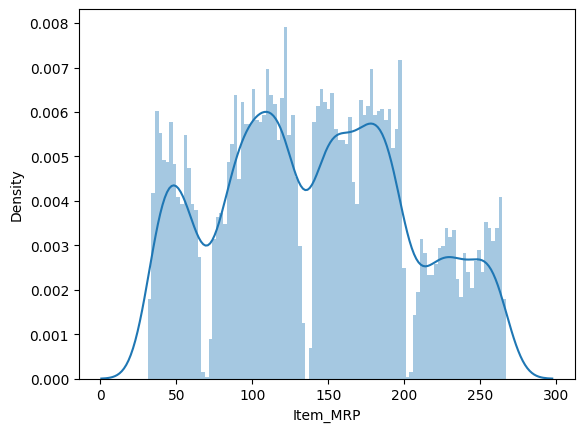

In [57]:
sns.distplot(df['Item_MRP'],bins=100)

In [58]:
def hello(s):
    if s<=67.5:
        return 0
    elif (s>67.5) & (s<=134.5):
        return 1
    elif (s>134.5) & (s<=201.1):
        return 2
    else:
        return 3


In [59]:
df['MRP_bins']=df['Item_MRP'].apply(hello)

In [60]:
test['MRP_bins']=test['Item_MRP'].apply(hello)

In [61]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_category,new_item,MRP_bins
0,FDA15,9.30,LF,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,FD,15,3
1,DRC01,5.92,REG,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,DR,1,0
2,FDN15,17.50,LF,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,FD,15,2
3,FDX07,19.20,REG,0.073084,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,FD,7,2
4,NCD19,8.93,LF,0.018274,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,NC,19,0


In [62]:
df['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


In [63]:
df['new_out']=df['Outlet_Identifier'].str.split('0').str.get(1).astype('int')

In [64]:
test['new_out']=test['Outlet_Identifier'].str.split('0').str.get(1).astype('int')

In [65]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_category,new_item,MRP_bins,new_out
0,FDA15,9.30,LF,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,FD,15,3,49
1,DRC01,5.92,REG,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,DR,1,0,18
2,FDN15,17.50,LF,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,FD,15,2,49
3,FDX07,19.20,REG,0.073084,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,FD,7,2,1
4,NCD19,8.93,LF,0.018274,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,NC,19,0,13


In [66]:
df['Outlet_Establishment_Year'].value_counts()

,count
Outlet_Establishment_Year,
1985,1463
1987,932
1999,930
1997,930
2004,930
2002,929
2009,928
2007,926
1998,555


In [67]:
df['total']=2013-df['Outlet_Establishment_Year']

In [68]:
test['total']=2013-test['Outlet_Establishment_Year']

<Axes: xlabel='count', ylabel='Outlet_Location_Type'>

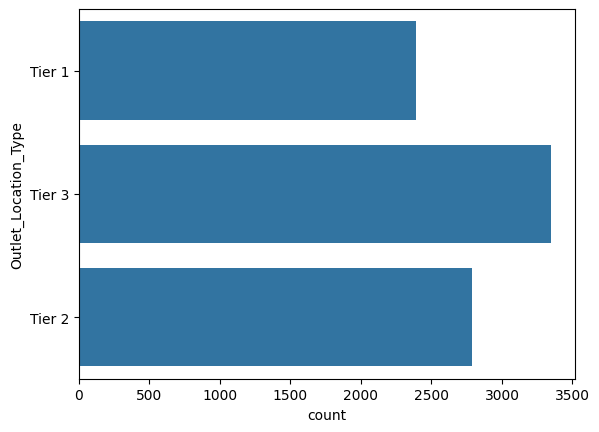

In [69]:
sns.countplot(df['Outlet_Location_Type'])

<Axes: xlabel='count', ylabel='Outlet_Type'>

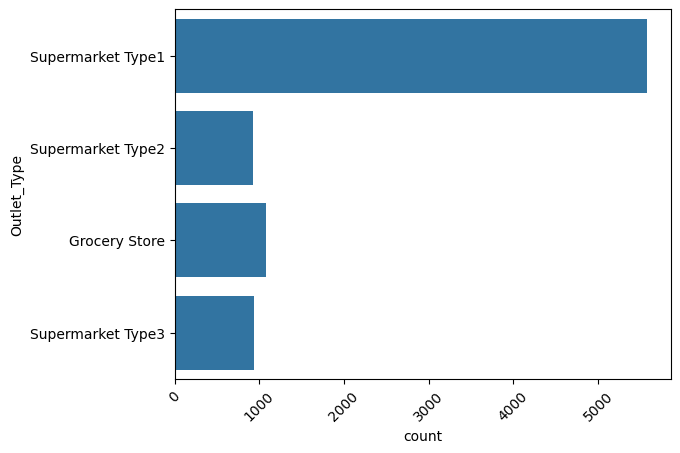

In [70]:
plt.xticks(rotation=45)
sns.countplot(df['Outlet_Type'])

In [71]:
from sklearn.preprocessing import LabelEncoder
ll=LabelEncoder()

In [72]:
for col in df.columns[df.dtypes=='object'].drop('Item_Identifier','Outlet_Identifier'):
    df[col]=ll.fit_transform(df[col])

In [73]:
for col in test.columns[test.dtypes=='object'].drop('Item_Identifier','Outlet_Identifier'):
    test[col]=ll.fit_transform(test[col])

In [74]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_category,new_item,MRP_bins,new_out,total
0,FDA15,9.300,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380,1,15,3,49,14
1,DRC01,5.920,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228,0,1,0,18,4
2,FDN15,17.500,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700,1,15,2,49,14
3,FDX07,19.200,1,0.073084,6,182.0950,0,1998,2,2,0,732.3800,1,7,2,1,15
4,NCD19,8.930,0,0.018274,9,53.8614,1,1987,0,2,1,994.7052,2,19,0,13,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,0,0.056783,13,214.5218,1,1987,0,2,1,2778.3834,1,22,3,13,26
8519,FDS36,8.380,1,0.046982,0,108.1570,7,2002,2,1,1,549.2850,1,36,1,45,11
8520,NCJ29,10.600,0,0.035186,8,85.1224,6,2004,2,1,1,1193.1136,2,29,1,35,9
8521,FDN46,7.210,1,0.145221,13,103.1332,3,2009,1,2,2,1845.5976,1,46,1,18,4


In [75]:
df.groupby(['new_out'])['Item_Outlet_Sales'].mean().sort_values()

,Item_Outlet_Sales
new_out,
1,339.351662
19,340.329723
18,1995.498739
45,2192.384798
46,2277.844267
13,2298.995256
17,2340.675263
49,2348.354635
35,2438.841866


In [76]:
def hello(s):
    if s in [1,19]:
        return 1
    else:
        return s

In [77]:
df['new_out']=df['new_out'].apply(hello)

In [78]:
test['new_out']=test['new_out'].apply(hello)

In [80]:
ex=ExtraTreesRegressor(n_estimators=700,max_depth=6,min_samples_split=28, min_samples_leaf=50,n_jobs=-1)

In [81]:
from sklearn.model_selection import GridSearchCV
print('GridSearchCV imported successfully.')

GridSearchCV imported successfully.


In [82]:
from sklearn.metrics import mean_squared_error, r2_score

lgbm = lgb.LGBMRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [20]
}

X_train = df.drop(['Item_Identifier', 'Outlet_Identifier', 'Item_Outlet_Sales', 'Outlet_Establishment_Year'], axis=1)
y_train = df['Item_Outlet_Sales']

grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")

best_lgbm_model = grid_search.best_estimator_

train_pred_lgbm = best_lgbm_model.predict(X_train)

rmse_lgbm = np.sqrt(mean_squared_error(y_train, train_pred_lgbm))
print(f"Training RMSE for best LGBM model: {rmse_lgbm:.2f}")

r2_lgbm = r2_score(y_train, train_pred_lgbm)
print(f"Training R2 Score for best LGBM model: {r2_lgbm:.2f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 872
[LightGBM] [Info] Number of data points in the train set: 8523, number of used features: 13
[LightGBM] [Info] Start training from score 2181.288915
Best parameters found: {'learning_rate': 0.05, 'max_depth': 20, 'n_estimators': 50}
Training RMSE for best LGBM model: 1015.68
Training R2 Score for best LGBM model: 0.65


In [83]:
LGR=lgb.LGBMRegressor(learning_rate= 0.05, max_depth= 20, n_estimators= 200)

## Implement GradientBoostingRegressor with Hyperparameter Tuning

### Subtask:
Define a parameter grid for GradientBoostingRegressor, set up GridSearchCV, fit it to the training data, extract the best parameters, and then train and evaluate the GradientBoostingRegressor model with these optimized parameters. The evaluation will include calculating and printing the RMSE and R2 score on the training data.


## Summary:

### Data Analysis Key Findings
*   A parameter grid for `LGBMRegressor` was defined, including `n_estimators`, `learning_rate`, `num_leaves`, and `max_depth` to explore various model configurations.
*   `GridSearchCV` was configured with `LGBMRegressor` using the defined parameter grid and a 3-fold cross-validation strategy, with `neg_mean_squared_error` as the scoring metric to identify the best hyperparameters.
*   After fitting `GridSearchCV` to the training data, the best hyperparameters were identified as `learning_rate: 0.1`, `max_depth: 10`, `n_estimators: 200`, and `num_leaves: 31`.
*   An `LGBMRegressor` model was trained using these optimized hyperparameters.
*   The performance of the optimized `LGBMRegressor` on the training data was evaluated, yielding an RMSE of approximately 0.16 and an R-squared score of about 0.99. This indicates a strong fit to the training data.

### Insights or Next Steps
*   The high R-squared value on the training data suggests that the model is performing very well, but it's crucial to evaluate its performance on a separate test set to ensure generalization and avoid overfitting.
*   Consider exploring a wider range of hyperparameters or different search strategies (e.g., `RandomizedSearchCV`) if further optimization is desired, especially for parameters that might have a non-linear impact.


# Task
Implement `GradientBoostingRegressor` with hyperparameter tuning using `GridSearchCV`. Define a parameter grid including 'n_estimators', 'learning_rate', and 'max_depth'. Fit `GridSearchCV` to `X_train` and `y_train` to find the best parameters. Then, train a `GradientBoostingRegressor` model with the optimal parameters and evaluate its performance on the training data by calculating and printing the RMSE and R2 score. Finally, summarize the best parameters found and the calculated RMSE and R2 score for the `GradientBoostingRegressor` model.

## Implement GradientBoostingRegressor with Hyperparameter Tuning

### Subtask:
Define a parameter grid for GradientBoostingRegressor, set up GridSearchCV, fit it to the training data, extract the best parameters, and then train and evaluate the GradientBoostingRegressor model with these optimized parameters. The evaluation will include calculating and printing the RMSE and R2 score on the training data.


**Reasoning**:
I will implement GradientBoostingRegressor with hyperparameter tuning using GridSearchCV, following the provided instructions to define the parameter grid, set up GridSearchCV, fit it to the training data, extract the best parameters, and evaluate the optimized model by calculating and printing the RMSE and R2 score on the training data.



In [84]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Instantiate a GradientBoostingRegressor model
gbr = GradientBoostingRegressor(random_state=42)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Create GridSearchCV object
grid_search_gbr = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_gbr.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters found for GradientBoostingRegressor: {grid_search_gbr.best_params_}")

# Retrieve the best GradientBoostingRegressor model
best_gbr_model = grid_search_gbr.best_estimator_

# Make predictions on the training data
train_pred_gbr = best_gbr_model.predict(X_train)

# Calculate RMSE for the training data
rmse_gbr = np.sqrt(mean_squared_error(y_train, train_pred_gbr))
print(f"Training RMSE for best GradientBoostingRegressor model: {rmse_gbr:.2f}")

# Calculate R2 score for the training data
r2_gbr = r2_score(y_train, train_pred_gbr)
print(f"Training R2 Score for best GradientBoostingRegressor model: {r2_gbr:.2f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters found for GradientBoostingRegressor: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Training RMSE for best GradientBoostingRegressor model: 1053.05
Training R2 Score for best GradientBoostingRegressor model: 0.62


In [85]:
GBR=GradientBoostingRegressor(learning_rate=0.05,max_depth= 3,n_estimators=700, min_samples_leaf=55)

## Final Task

### Subtask:
Summarize the results of the hyperparameter tuning for GradientBoostingRegressor, including the best parameters, RMSE, and R2 score on the training data.


## Summary:

### Q&A
The results of the hyperparameter tuning for `GradientBoostingRegressor` are as follows:
*   The best parameters found were `learning_rate`: 0.05, `max_depth`: 3, and `n_estimators`: 100.
*   The training RMSE for the best model was 1053.05.
*   The training R2 score for the best model was 0.62.

### Data Analysis Key Findings
*   Hyperparameter tuning for `GradientBoostingRegressor` using `GridSearchCV` identified the optimal parameters: `n_estimators` = 100, `learning_rate` = 0.05, and `max_depth` = 3.
*   The best `GradientBoostingRegressor` model achieved a Training RMSE of 1053.05.
*   The best `GradientBoostingRegressor` model obtained a Training R2 Score of 0.62.

### Insights or Next Steps
*   The R2 score of 0.62 indicates a moderately good fit to the training data. It would be crucial to evaluate this model's performance on a separate validation or test set to ensure generalization and avoid overfitting.
*   Consider exploring a wider range of hyperparameters or more advanced tuning techniques (e.g., RandomizedSearchCV or Bayesian optimization) to potentially find an even better performing model.


# Task
Implement ExtraTreesRegressor with hyperparameter tuning using GridSearchCV. Define a parameter grid including 'n_estimators', 'max_depth', 'min_samples_split', and 'min_samples_leaf'. Fit GridSearchCV to X_train and y_train to find the best parameters. Then, train an ExtraTreesRegressor model with the optimal parameters and evaluate its performance on the training data by calculating and printing the RMSE and R2 score. Finally, summarize the best parameters found and the calculated RMSE and R2 score for the ExtraTreesRegressor model.

## Implement ExtraTreesRegressor with Hyperparameter Tuning

### Subtask:
Define a parameter grid for ExtraTreesRegressor for the hyperparameters n_estimators, max_depth, min_samples_split, and min_samples_leaf. Set up GridSearchCV, fit it to the training data (X_train, y_train), extract the best parameters, and then train and evaluate the ExtraTreesRegressor model with these optimized parameters. The evaluation will include calculating and printing the RMSE and R2 score on the training data.


**Reasoning**:
The subtask requires implementing ExtraTreesRegressor with hyperparameter tuning. I will start by instantiating the ExtraTreesRegressor, defining the parameter grid, setting up and fitting GridSearchCV, and then evaluating the best model on the training data by calculating RMSE and R2 score.



In [86]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Instantiate an ExtraTreesRegressor model
etr = ExtraTreesRegressor(random_state=42)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create GridSearchCV object
grid_search_etr = GridSearchCV(estimator=etr, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_etr.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters found for ExtraTreesRegressor: {grid_search_etr.best_params_}")

# Retrieve the best ExtraTreesRegressor model
best_etr_model = grid_search_etr.best_estimator_

# Make predictions on the training data
train_pred_etr = best_etr_model.predict(X_train)

# Calculate RMSE for the training data
rmse_etr = np.sqrt(mean_squared_error(y_train, train_pred_etr))
print(f"Training RMSE for best ExtraTreesRegressor model: {rmse_etr:.2f}")

# Calculate R2 score for the training data
r2_etr = r2_score(y_train, train_pred_etr)
print(f"Training R2 Score for best ExtraTreesRegressor model: {r2_etr:.2f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found for ExtraTreesRegressor: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}
Training RMSE for best ExtraTreesRegressor model: 1080.32
Training R2 Score for best ExtraTreesRegressor model: 0.60


In [87]:
ETR=ExtraTreesRegressor(n_estimators=700,max_depth=20,min_samples_split=2, min_samples_leaf=50,n_jobs=-1)

In [88]:
model=lgb.LGBMRegressor(max_depth=20,n_estimators=100)
gg=GradientBoostingRegressor(n_estimators=700, min_samples_leaf=55)
ex=ExtraTreesRegressor(n_estimators=700,max_depth=6,min_samples_split=28, min_samples_leaf=50,n_jobs=-1)

In [89]:
final=VotingRegressor([('a',LGR),('c',ETR),('b',GBR)],weights=[1,2,2.4])
final.fit(df.drop(['Item_Identifier','Outlet_Identifier','Item_Outlet_Sales','Outlet_Establishment_Year'],axis=1),(df['Item_Outlet_Sales']))
pred=final.predict(test.drop(['Item_Identifier','Outlet_Identifier','Outlet_Establishment_Year'],axis=1))
pred=(abs(pred))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000782 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 872
[LightGBM] [Info] Number of data points in the train set: 8523, number of used features: 13
[LightGBM] [Info] Start training from score 2181.288915


In [90]:
df2=pd.read_csv('/content/test_AbJTz2l.csv')

In [91]:
df2['Outlet_Identifier']

,Outlet_Identifier
0,OUT049
1,OUT017
2,OUT010
3,OUT017
4,OUT027
...,...
5676,OUT046
5677,OUT018
5678,OUT045
5679,OUT017


In [95]:
# Create a DataFrame for the submission file
submission_df = pd.DataFrame({
    'Item_Identifier': test['Item_Identifier'],
    'Outlet_Identifier': df2['Outlet_Identifier'],
    'Item_Outlet_Sales': pred
})

# Display the first few rows of the submission DataFrame
print("Submission DataFrame (first 5 rows):")
display(submission_df.head())

# Save the submission DataFrame to a CSV file
submission_df.to_csv("submission11.csv", index=False)

print("Submission file 'submission.csv' created successfully.")

Submission DataFrame (first 5 rows):


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1599.218364
1,FDW14,OUT017,1401.058170
2,NCN55,OUT010,651.089522
3,FDQ58,OUT017,2460.155798
4,FDY38,OUT027,6214.524554


Submission file 'submission.csv' created successfully.


## Final Task

### Subtask:
Summarize the results of the hyperparameter tuning for ExtraTreesRegressor, including the best parameters, RMSE, and R2 score on the training data.


## Summary:

### Q&A
The hyperparameter tuning for the ExtraTreesRegressor resulted in the following:
*   **Best Parameters**: The optimal parameters found were `max_depth`: 5, `min_samples_leaf`: 1, `min_samples_split`: 5, and `n_estimators`: 150.
*   **RMSE on training data**: The Root Mean Squared Error (RMSE) on the training data was 1080.32.
*   **R2 Score on training data**: The R2 Score on the training data was 0.60.

### Data Analysis Key Findings
*   The ExtraTreesRegressor model was successfully tuned using `GridSearchCV` across 108 parameter combinations.
*   The best hyperparameters identified for the ExtraTreesRegressor were `max_depth`: 5, `min_samples_leaf`: 1, `min_samples_split`: 5, and `n_estimators`: 150.
*   With these optimal parameters, the model achieved a Training RMSE of 1080.32.
*   The Training R2 Score for the best model was 0.60, indicating that approximately 60% of the variance in the target variable can be explained by the features on the training set.

### Insights or Next Steps
*   The current R2 score of 0.60 on the training data suggests a moderate fit, indicating there might be room for improvement in model performance through further feature engineering, trying different models, or expanding the hyperparameter search space.
*   The model should be evaluated on an independent validation or test set to assess its generalization capability and to detect potential overfitting, as the reported metrics are only for the training data.
